In [17]:
import wandb
import os

api = wandb.Api()

# # List all runs in your project
# runs = api.runs("weissma6-zhaw-school-of-engineering/UR10_pick_ppo")

# print("Available runs:")
# for run in runs:
#     print(f"  ID: {run.id}  |  Name: {run.name}  |  State: {run.state}")


# '''
# This will show you the exact run IDs. Common issues:

# 1. **Run name ≠ Run ID** — W&B has both `run.name` (display name) and `run.id` (unique identifier). You might be using the name instead of the ID.

# 2. **Check in W&B UI** — Go to your run's page, the URL will §be:

# https://wandb.ai/weissma6/UR10_pick_ppo/runs/<actual_run_id>
# '''

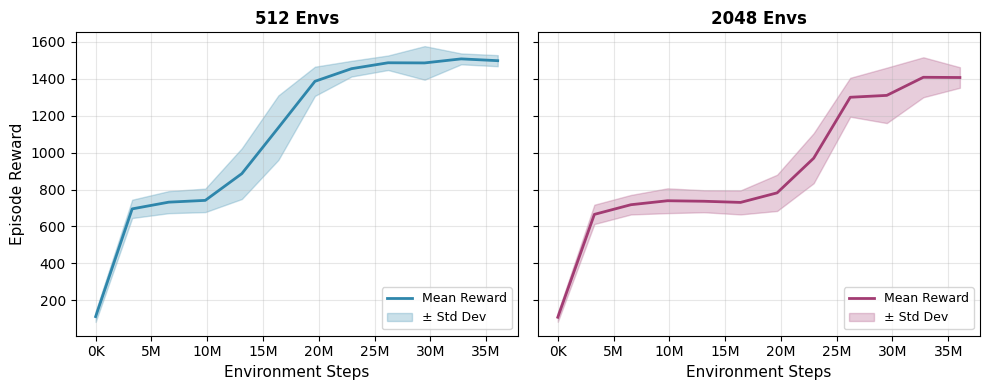

In [18]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Fetch data from W&B ---
api = wandb.Api()
user = "weissma6-zhaw-school-of-engineering"
project = "UR10_pick_ppo"
runs = {
    "512 Envs": "lift_512Envs_20260124_164012_5264",
    "2048 Envs": "lift_2048Envs_20260124_163951_172",
}

data = {}
for label, run_id in runs.items():
    run = api.run(f"{user}/{project}/{run_id}")
    history = run.history(keys=["eval/episode_reward", "eval/episode_reward_std"])
    history = history.dropna()  # Remove NaN rows
    data[label] = history

# --- Plot ---
fig, axes = plt.subplots(1, len(runs), figsize=(5 * len(runs), 4), sharey=True)

# Color palette (adjust as needed)
colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"]

for ax, (label, df), color in zip(axes, data.items(), colors):
    steps = df["_step"] if "_step" in df.columns else df.index
    mean = df["eval/episode_reward"]
    std = df["eval/episode_reward_std"]
    
    # Plot mean line
    ax.plot(steps, mean, color=color, linewidth=2, label="Mean Reward")
    
    # Plot std band
    ax.fill_between(
        steps,
        mean - std,
        mean + std,
        color=color,
        alpha=0.25,
        label="± Std Dev"
    )
    
    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)

    # Format x-axis with millions
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
    )

axes[0].set_ylabel("Episode Reward", fontsize=11)

plt.tight_layout()
plt.savefig("reward_comparison.pdf", bbox_inches="tight", dpi=300)
plt.savefig("reward_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

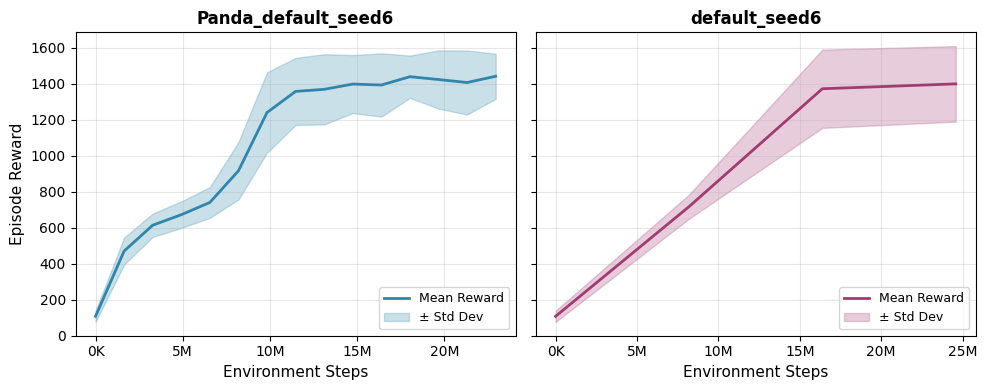

In [19]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Fetch data from W&B ---
api = wandb.Api()
user = "weissma6-zhaw-school-of-engineering"
project = "panda_pick_ppo"
runs = {
    "Panda_default_seed6": "2hcb0tlw",
    "default_seed6": "umm9hky6",
}
# "default_seed6": "umm9hky6",

data = {}
for label, run_id in runs.items():
    run = api.run(f"{user}/{project}/{run_id}")
    history = run.history(keys=["eval/episode_reward", "eval/episode_reward_std"])
    history = history.dropna()  # Remove NaN rows
    data[label] = history

# --- Plot ---
fig, axes = plt.subplots(1, len(runs), figsize=(5 * len(runs), 4), sharey=True)

# Color palette (adjust as needed)
colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"]

for ax, (label, df), color in zip(axes, data.items(), colors):
    steps = df["_step"] if "_step" in df.columns else df.index
    mean = df["eval/episode_reward"]
    std = df["eval/episode_reward_std"]
    
    # Plot mean line
    ax.plot(steps, mean, color=color, linewidth=2, label="Mean Reward")
    
    # Plot std band
    ax.fill_between(
        steps,
        mean - std,
        mean + std,
        color=color,
        alpha=0.25,
        label="± Std Dev"
    )
    
    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)

    # Format x-axis with millions
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
    )

axes[0].set_ylabel("Episode Reward", fontsize=11)

plt.tight_layout()
# plt.savefig("reward_comparison.pdf", bbox_inches="tight", dpi=300)
# plt.savefig("reward_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

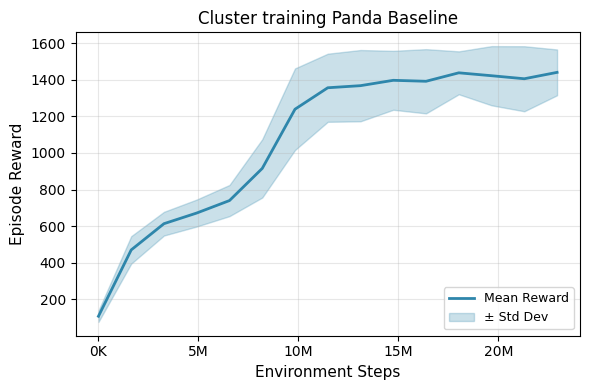

In [20]:
# --- Fetch data from W&B ---
api = wandb.Api()
user = "weissma6-zhaw-school-of-engineering"
project = "panda_pick_ppo"
label = "Panda_default_seed6"
run_id = "2hcb0tlw"

run = api.run(f"{user}/{project}/{run_id}")
df = run.history(keys=["eval/episode_reward", "eval/episode_reward_std"]).dropna()

SAVE_DIR = "run_graphs/"
RUN_DIR = os.path.join(SAVE_DIR, label)

fig, ax = plt.subplots(figsize=(6, 4))

label, df = list(data.items())[0]
color = "#2E86AB"

steps = df["_step"] if "_step" in df.columns else df.index
mean = df["eval/episode_reward"]
std = df["eval/episode_reward_std"]

ax.plot(steps, mean, color=color, linewidth=2, label="Mean Reward")
ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.25, label="± Std Dev")

ax.set_xlabel("Environment Steps", fontsize=11)
ax.set_ylabel("Episode Reward", fontsize=11)
ax.set_title("Cluster training Panda Baseline", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=9)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
)

plt.savefig(os.path.join(RUN_DIR, 'Training_Reward.png'), dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [21]:
def plot_training_reward(user, project, run_id, title=None, save_dir="run_graphs", color="#2E86AB"):
    api = wandb.Api()
    run = api.run(f"{user}/{project}/{run_id}")
    df = run.history(keys=["eval/episode_reward", "eval/episode_reward_std"]).dropna()

    run_dir = os.path.join(save_dir, run_id)
    os.makedirs(run_dir, exist_ok=True)

    steps = df["_step"] if "_step" in df.columns else df.index
    mean = df["eval/episode_reward"]
    std = df["eval/episode_reward_std"]

    # ── Collect runtime ──
    summary = run.summary
    runtime = summary.get("_runtime")
    if runtime:
        mins = runtime / 60
        runtime_str = f"Runtime: {mins:.1f} min ({runtime:.0f}s)"
    else:
        try:
            from datetime import datetime
            t0 = datetime.fromisoformat(run.created_at.replace("Z", "+00:00"))
            t1 = datetime.fromisoformat((run.heartbeat_at or run.updated_at).replace("Z", "+00:00"))
            mins = (t1 - t0).total_seconds() / 60
            runtime_str = f"Duration: {mins:.0f} min"
        except:
            runtime_str = "Runtime: N/A"

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(steps, mean, color=color, linewidth=2, label="Mean Reward")
    ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.25, label="± Std Dev")
    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_ylabel("Episode Reward", fontsize=11)
    ax.set_title(title or run.name, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
    )

    ax.text(0.5, -0.22, runtime_str, transform=ax.transAxes,
            ha="center", fontsize=9, color="gray", style="italic")

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.22)
    plt.savefig(os.path.join(run_dir, "Training_Reward.png"), dpi=300, bbox_inches="tight")
    plt.show()
    return None

In [22]:
# # List all runs in your project
# runs = api.runs("weissma6-zhaw-school-of-engineering/ur10_pick_ppo")

# print(f"Last 10 runs:\n")
# print(f"  {'Run ID':<40} {'Name':<50} {'State'}")
# print(f"  {'─'*40} {'─'*50} {'─'*10}")
# for run in list(runs)[-10:]:
#     print(f"  {run.id:<40} {run.name:<50} {run.state}")

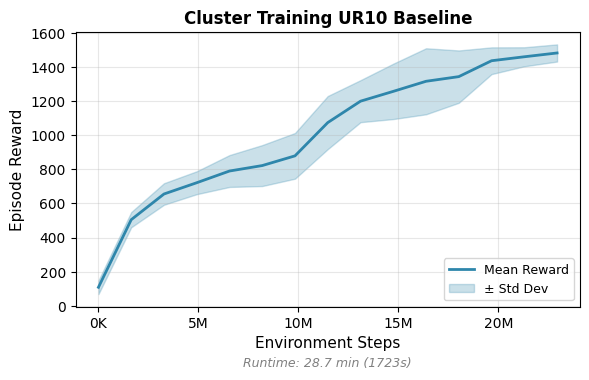

In [23]:
plot_training_reward(
    user="weissma6-zhaw-school-of-engineering",
    project="ur10_pick_ppo",
    run_id="4001_FR130_limp0.990.995_Damp=0.5_DR_off_20260208_170954_8864",
    title="Cluster Training UR10 Baseline",
)

In [24]:
def plot_multi_training_reward(user, project, run_dict, title=None, save_path="multi_training.png", figsize=(14, 5)):
    """
    run_dict: {"label": "run_id", ...}
    Left:  all runs overlaid
    Right: cross-run mean ± std at each eval step
    Below: mean ± std of runtime
    """
    api = wandb.Api()
    colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#3CB371", "#6A0DAD", "#FF6B6B", "#4ECDC4"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, sharey=True)

    all_means = []
    all_steps = []
    runtimes = []

    for idx, (label, run_id) in enumerate(run_dict.items()):
        run = api.run(f"{user}/{project}/{run_id}")
        df = run.history(keys=["eval/episode_reward", "eval/episode_reward_std"]).dropna()

        steps = df["_step"].values
        mean = df["eval/episode_reward"].values
        std = df["eval/episode_reward_std"].values
        color = colors[idx % len(colors)]

        # Left plot: individual curves
        ax1.plot(steps, mean, color=color, linewidth=1.5, label=label, alpha=0.85)
        ax1.fill_between(steps, mean - std, mean + std, color=color, alpha=0.1)

        all_means.append(mean)
        all_steps.append(steps)

        # Collect runtime
        rt = run.summary.get("_runtime")
        if rt:
            runtimes.append(rt)

    # Right plot: cross-run mean ± std
    # Interpolate all runs onto common step grid
    min_len = min(len(s) for s in all_steps)
    common_steps = all_steps[0][:min_len]
    stacked = np.array([m[:min_len] for m in all_means])
    cross_mean = stacked.mean(axis=0)
    cross_std = stacked.std(axis=0)

    ax2.plot(common_steps, cross_mean, color="black", linewidth=2, label="Cross-run mean")
    ax2.fill_between(common_steps, cross_mean - cross_std, cross_mean + cross_std,
                     color="gray", alpha=0.3, label=f"± Std (n={len(run_dict)})")

    # Formatting
    for ax in (ax1, ax2):
        ax.set_xlabel("Environment Steps", fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc="lower right")
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
        )

    ax1.set_ylabel("Episode Reward", fontsize=11)
    ax1.set_title("Individual Runs", fontsize=12, fontweight="bold")
    ax2.set_title("Cross-Run Mean ± Std", fontsize=12, fontweight="bold")

    if title:
        fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)

    # Runtime info below
    if runtimes:
        rt_mean = np.mean(runtimes) / 60
        rt_std = np.std(runtimes) / 60
        rt_str = f"Runtime: {rt_mean:.1f} ± {rt_std:.1f} min  (n={len(runtimes)})"
    else:
        rt_str = "Runtime: N/A"

    fig.text(0.5, -0.04, rt_str, ha="center", fontsize=10, color="gray", style="italic")

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [25]:
def plot_project_runs(user, project, n=None, title=None, save_path=None, figsize=(14, 5)):
    """
    Fetch runs from W&B and plot them.
    n=None → all runs, n=10 → last 10 runs.
    """
    api = wandb.Api()
    runs = list(api.runs(f"{user}/{project}"))

    if n is not None:
        runs = runs[:n]  # most recent first

    print(f"Plotting {len(runs)} runs from {project}\n")

    colors = plt.cm.tab20.colors
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, sharey=True)

    all_means = []
    all_steps = []
    runtimes = []
    plotted = 0

    for idx, run in enumerate(runs):
        try:
            df = run.history(keys=["eval/episode_reward", "eval/episode_reward_std"]).dropna()
            if len(df) < 2:
                print(f"  ⚠ {run.name}: not enough data, skipping")
                continue

            steps = df["_step"].values
            mean = df["eval/episode_reward"].values
            std = df["eval/episode_reward_std"].values
            color = colors[plotted % len(colors)]

            ax1.plot(steps, mean, color=color, linewidth=1.2, label=run.name, alpha=0.8)
            ax1.fill_between(steps, mean - std, mean + std, color=color, alpha=0.05)

            all_means.append(mean)
            all_steps.append(steps)
            plotted += 1

            rt = run.summary.get("_runtime")
            if rt:
                runtimes.append(rt)

            print(f"  ✓ {run.name}  (final={mean[-1]:.1f}, peak={mean.max():.1f})")

        except Exception as e:
            print(f"  ✗ {run.name}: {e}")

    # Right plot: cross-run mean ± std
    if all_means:
        min_len = min(len(m) for m in all_means)
        common_steps = all_steps[0][:min_len]
        stacked = np.array([m[:min_len] for m in all_means])
        cross_mean = stacked.mean(axis=0)
        cross_std = stacked.std(axis=0)

        ax2.plot(common_steps, cross_mean, color="black", linewidth=2, label="Cross-run mean")
        ax2.fill_between(common_steps, cross_mean - cross_std, cross_mean + cross_std,
                         color="gray", alpha=0.3, label=f"± Std (n={plotted})")

    for ax in (ax1, ax2):
        ax.set_xlabel("Environment Steps", fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
        )

    ax1.set_ylabel("Episode Reward", fontsize=11)
    ax1.set_title("Individual Runs", fontsize=12, fontweight="bold")
    ax1.legend(fontsize=6, loc="lower right", ncol=2)
    ax2.set_title("Cross-Run Mean ± Std", fontsize=12, fontweight="bold")
    ax2.legend(fontsize=9, loc="lower right")

    fig.suptitle(title or f"{project} ({plotted} runs)", fontsize=14, fontweight="bold", y=1.02)

    if runtimes:
        rt_str = f"Runtime: {np.mean(runtimes)/60:.1f} ± {np.std(runtimes)/60:.1f} min  (n={len(runtimes)})"
    else:
        rt_str = "Runtime: N/A"
    fig.text(0.5, -0.04, rt_str, ha="center", fontsize=10, color="gray", style="italic")

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

Plotting 20 runs from UR10_pick_ppo

  ✗ Test new geometry: unsupported operand type(s) for -: 'str' and 'str'
  ⚠ Tiny1: not enough data, skipping
  ⚠ Tiny1: not enough data, skipping
  ✓ fast  (final=598.0, peak=632.5)
  ⚠ quickest_20260117_092424_623: not enough data, skipping
  ⚠ meaningful_video_20260117_102721_4575: not enough data, skipping
  ✓ default_short_seed 1  (final=513.3, peak=513.3)
  ✓ default_short_seed 1  (final=510.9, peak=510.9)
  ✓ default_short_seed 1  (final=510.7, peak=510.7)
  ✓ default_short_seed 100k  (final=510.9, peak=510.9)
  ✓ default_short_1k  (final=559.9, peak=559.9)
  ✓ sweep_part2_1028_20260117_170531_7924  (final=539.0, peak=539.0)
  ✓ baseling_fast_20260118_104318_2201  (final=483.5, peak=483.5)
  ✓ baseling_20260118_145206_4513  (final=495.2, peak=495.2)
  ✓ baseling_closeup_20260118_145215_7565  (final=494.5, peak=494.5)
  ✓ baseling_20260118_155410_358  (final=81.8, peak=81.8)
  ✗ baseling_closeup_20260118_155821_6597: unsupported operand type(

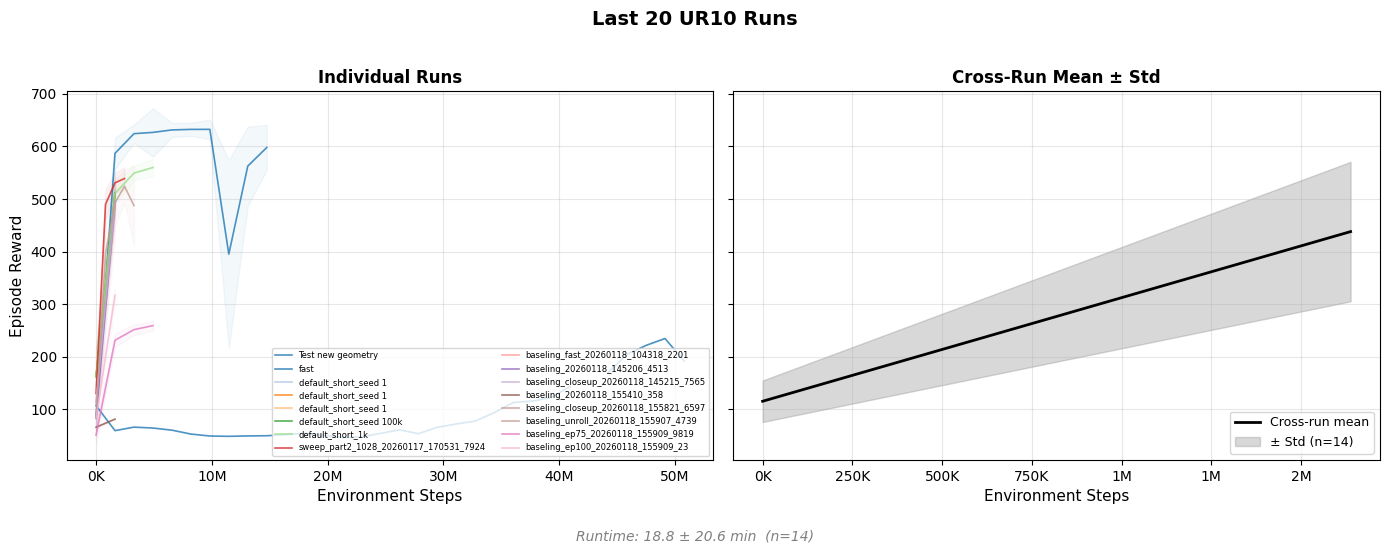

In [26]:
# # All runs
# plot_project_runs("weissma6-zhaw-school-of-engineering", "UR10_pick_ppo",
#                   title="All UR10 Runs", save_path="run_graphs/all_ur10.png")

# Last 5 runs only
plot_project_runs("weissma6-zhaw-school-of-engineering", "UR10_pick_ppo", n=20,
                  title="Last 20 UR10 Runs", save_path="run_graphs/last20_ur10.png")